In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset (Since both files are in the same folder, this is perfect)
dataset = pd.read_csv("Life Expectancy Data.csv")

# 2. Fix the hidden spaces in the column names
dataset.columns = dataset.columns.str.strip()

# 3. Change the text to numbers (Developing = 0, Developed = 1)
dataset['Status'] = dataset['Status'].map({'Developing': 0, 'Developed': 1})

# 4. Drop the 'Country' column and the duplicate columns
dataset = dataset.drop(columns=['Country', 'infant deaths', 'thinness 5-9 years'])

# 5. Fill in the blank missing data with the average
dataset['Life expectancy'].fillna(dataset['Life expectancy'].mean(), inplace=True)
dataset.fillna(dataset.mean(), inplace=True)

# Print the final shape to prove it's clean and full
print("Cleaned dataset shape:", dataset.shape)
dataset.head()

Cleaned dataset shape: (2938, 19)


C:\Users\2003s\AppData\Local\Temp\ipykernel_6772\871003280.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['Life expectancy'].fillna(dataset['Life expectancy'].mean(), inplace=True)


,Year,Status,Life expectancy,Adult Mortality,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Income composition of resources,Schooling
0,2015,0,65.0,263.0,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,0.479,10.1
1,2014,0,59.9,271.0,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,0.476,10.0
2,2013,0,59.9,268.0,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,0.470,9.9
3,2012,0,59.5,272.0,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,0.463,9.8
4,2011,0,59.2,275.0,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,0.454,9.5


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Separate the Answers (y) from the Questions (x)
x = dataset.drop(columns=['Life expectancy'])
y = dataset['Life expectancy']

# 2. Hide 20% of the data for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Build the Random Forest (100 Trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Train the model (The Heavy Lifting)
rf_model.fit(x_train, y_train)

# 5. Take the exam and print the score
rf_pred = rf_model.predict(x_test)
print("Awesome! New Random Forest Score:", r2_score(y_test, rf_pred))

Awesome! New Random Forest Score: 0.9690529271649446


Top 10 Most Important Factors for Life Expectancy:
                            Feature  Importance
12                         HIV/AIDS    0.594295
2                   Adult Mortality    0.160546
16  Income composition of resources    0.143870
17                        Schooling    0.018612
7                               BMI    0.014583
8                 under-five deaths    0.013363
15             thinness  1-19 years    0.011458
3                           Alcohol    0.007415
0                              Year    0.006784
10                Total expenditure    0.005524


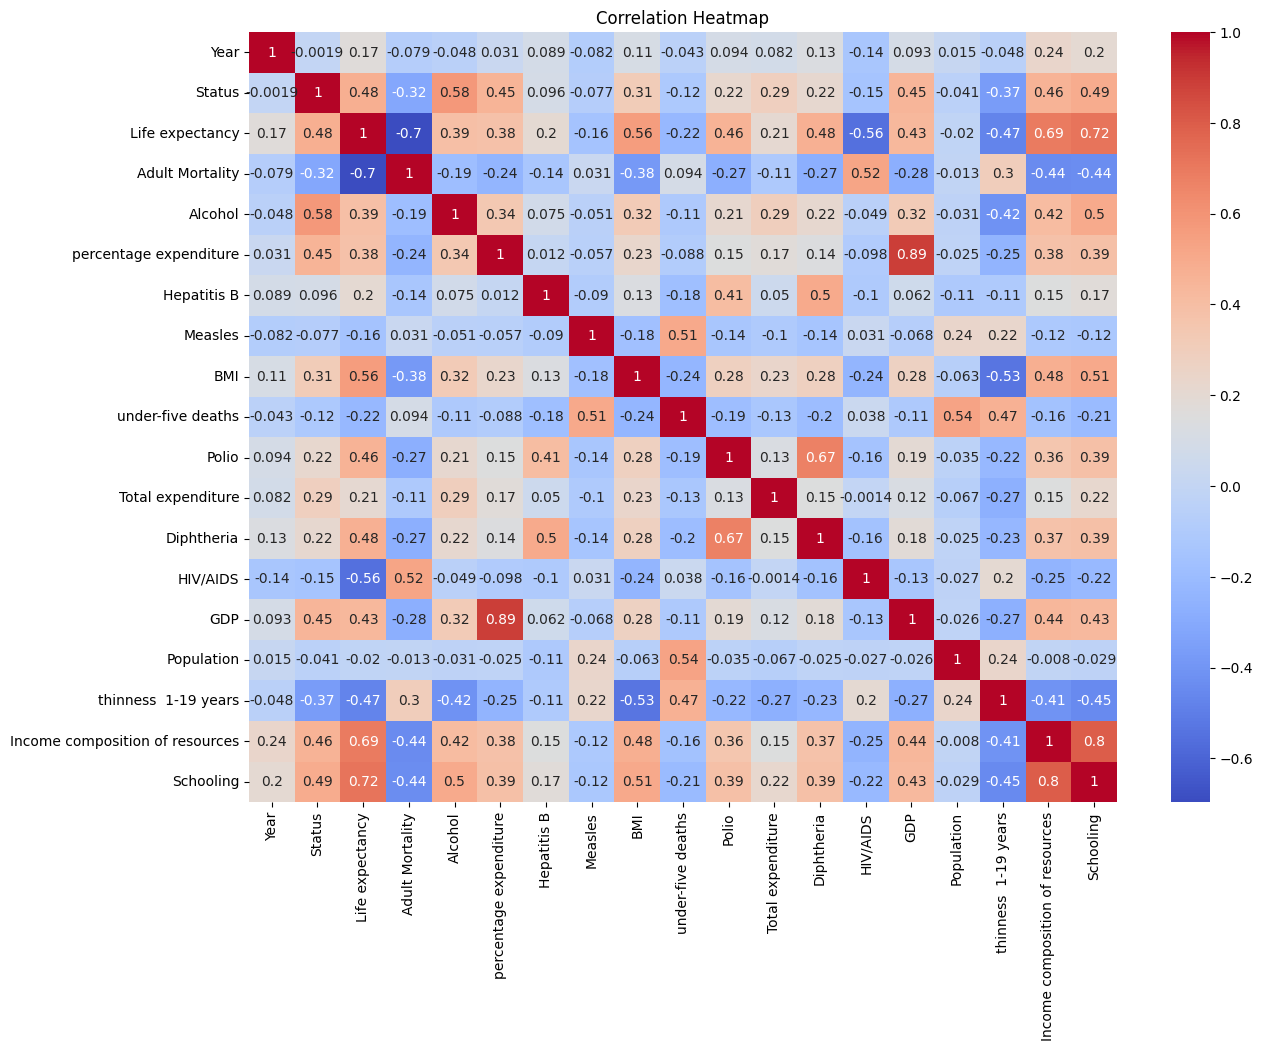

In [ ]:
# 1. Extract the internal ranking from the model
importances = rf_model.feature_importances_

# 2. Match the scores to the column names
feature_ranking = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
})

# 3. Print the top 10 factors
print("Top 10 Most Important Factors for Life Expectancy:")
print(feature_ranking.sort_values(by='Importance', ascending=False).head(10))

# 4. Draw the Heatmap (Your Exploratory Data Analysis)
plt.figure(figsize=(14,10))
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()